# NFFF SimNIBS Data Extraction Tutorial

**NeuroEM Flux Force Five (NFFF) — EEE 488 Capstone**

This notebook accompanies the **NFFF SimNIBS Quick-Start Tutorial**.

### Goal
Load the TMS finite-element result generated in Tutorial 01, inspect the stored electric-field data, isolate gray matter, calculate basic E-field statistics, and plot the gray-matter E-field distribution.

### Before running
1. Complete the standardized SimNIBS Tutorial 01 simulation using the `ernie` head model, Magstim 70-mm figure-8 coil, and C3 training position.
2. Place the generated `.msh` file in `simulations/tutorial_01`.
3. Open this notebook in JupyterLab.
4. Confirm that the selected kernel is **Python - SimNIBS**.

> **Important:** C3 is a reproducible training position only. It is **not** the final NFFF left-DLPFC research target.


## 1. Import the required Python packages

`mesh_io` is a module inside the SimNIBS Python package. It contains tools for reading and manipulating finite-element mesh (`.msh`) files.

The hierarchy is approximately:

`Python → simnibs package → mesh_io module → read_msh()`


In [1]:
from pathlib import Path

from simnibs import mesh_io
import numpy as np
import matplotlib.pyplot as plt


## 2. Locate your Tutorial 01 FEM result

The notebook uses the NFFF tutorial folder structure rather than a personal Windows drive path. This makes the notebook portable among team members.

Expected structure:

```text
NFFF Team Tutorial/
├── notebooks/
│   └── NFFF_SimNIBS_Data_Extraction_Tutorial.ipynb
└── simulations/
    └── tutorial_01/
        └── ernie_TMS_1-0001_Magstim_70mm_Fig8_scalar.msh
```

If you renamed the `.msh` file, change only the filename below.


In [2]:
# Determine the NFFF Team Tutorial root folder.
# This works when the notebook is opened from the "notebooks" folder
# and also tolerates a kernel started from the project root.

cwd = Path.cwd()
project_root = cwd.parent if cwd.name.lower() == "notebooks" else cwd

msh_path = (
    project_root
    / "simulations"
    / "tutorial_01"
    / "ernie_TMS_1-0001_Magstim_70mm_Fig8_scalar.msh"
)

print("Tutorial mesh:")
print(msh_path)

if not msh_path.exists():
    raise FileNotFoundError(
        "Tutorial .msh file not found. Check that your FEM result is in "
        "simulations/tutorial_01 and that the filename matches this notebook."
    )


Tutorial mesh:
G:\My Drive\ASU\capstone\NFFF Team Tutorial\simulations\tutorial_01\ernie_TMS_1-0001_Magstim_70mm_Fig8_scalar.msh


## 3. Load the FEM mesh

`read_msh()` reads the SimNIBS result file and creates a Python mesh object.

The tutorial mesh is large, so loading may take a little time.


In [3]:
mesh = mesh_io.read_msh(str(msh_path))

print("Mesh loaded successfully.")


Mesh loaded successfully.


## 4. Inspect the electric-field data stored in the mesh

For the standardized Tutorial 01 simulation, the element-data fields should include:

- `E` — vector electric field `(Ex, Ey, Ez)`
- `magnE` — scalar electric-field magnitude

\[
|E| = \sqrt{E_x^2 + E_y^2 + E_z^2}
\]

Units are **V/m**.


In [4]:
for i, field in enumerate(mesh.elmdata):
    print(i, field.field_name)


0 E
1 magnE


## 5. Extract electric-field magnitude (`magnE`)

The next line converts the FEM electric-field magnitude data into a NumPy array that we can analyze numerically.

This is the key transition from the FEM result to Python analysis.


In [5]:
# mesh.elmdata[0] = E
# mesh.elmdata[1] = magnE
# Units: V/m

magnE = mesh.elmdata[1].value

print("Number of magnE values =", magnE.size)
print("First 10 values:")
print(magnE[:10])


Number of magnE values = 5576894
First 10 values:
[1.03240518 0.1082099  0.39868216 0.0964751  0.08151312 0.02222278
 0.04439615 0.696996   0.16964148 0.0798948 ]


## 6. Inspect tissue/element tags

The FEM mesh contains multiple tissues. Therefore, statistics calculated indiscriminately over the entire mesh should **not** be described as cortical or gray-matter statistics.

For this introductory analysis we will select **gray matter**, which is tissue tag `2` in this model.


In [6]:
tags = mesh.elm.tag1

unique_tags, counts = np.unique(tags, return_counts=True)

print("Tissue/element tags present in the mesh:")
for tag, count in zip(unique_tags, counts):
    print(f"Tag {tag}: {count:,} elements")


Tissue/element tags present in the mesh:
Tag 1: 505,949 elements
Tag 2: 1,337,567 elements
Tag 3: 823,288 elements
Tag 5: 565,436 elements
Tag 6: 5,145 elements
Tag 7: 917,518 elements
Tag 8: 246,015 elements
Tag 9: 57,523 elements
Tag 10: 4,566 elements
Tag 1001: 249,041 elements
Tag 1002: 319,021 elements
Tag 1003: 121,846 elements
Tag 1005: 112,064 elements
Tag 1006: 2,524 elements
Tag 1007: 139,245 elements
Tag 1008: 138,429 elements
Tag 1009: 29,437 elements
Tag 1010: 2,280 elements


## 7. Select gray matter

A Boolean mask identifies which finite elements belong to gray matter. The original mesh is not modified; NumPy simply keeps the `magnE` values corresponding to elements for which the mask is `True`.


In [7]:
GRAY_MATTER = 2

gm_mask = (mesh.elm.tag1 == GRAY_MATTER)
magnE_gm = magnE[gm_mask]

print("Total magnE values =", magnE.size)
print("Gray-matter magnE values =", magnE_gm.size)


Total magnE values = 5576894
Gray-matter magnE values = 1337567


## 8. Calculate basic gray-matter E-field statistics

These are **element-wise** statistics over the selected gray-matter tetrahedral finite elements. More advanced NFFF analyses can later incorporate element-volume weighting, anatomical ROIs, depth, and focality metrics.

For the validated standardized Tutorial 01 run, approximate values were:

- Peak: **2.0475 V/m**
- Mean: **0.1726 V/m**
- 95th percentile: **0.4982 V/m**

Small differences should prompt a check of the simulation setup before proceeding.


In [8]:
print("----- Gray Matter Electric Field Statistics -----")

print("Peak E-field =", np.max(magnE_gm), "V/m")
print("Mean E-field =", np.mean(magnE_gm), "V/m")
print("95th percentile =", np.percentile(magnE_gm, 95), "V/m")


----- Gray Matter Electric Field Statistics -----
Peak E-field = 2.0474976455388467 V/m
Mean E-field = 0.17258417172688748 V/m
95th percentile = 0.4982133578686894 V/m


## 9. Plot the gray-matter E-field distribution

The histogram shows how electric-field magnitudes are distributed across the gray-matter finite elements.


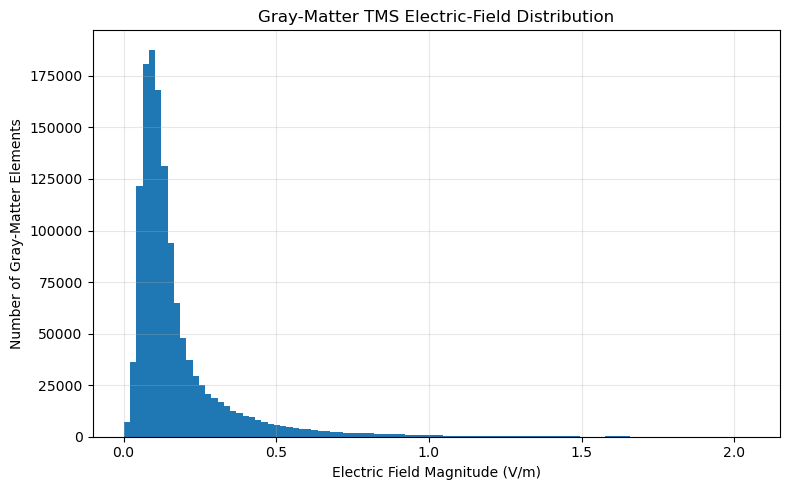

In [9]:
plt.figure(figsize=(8, 5))

plt.hist(magnE_gm, bins=100)

plt.xlabel("Electric Field Magnitude (V/m)")
plt.ylabel("Number of Gray-Matter Elements")
plt.title("Gray-Matter TMS Electric-Field Distribution")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()


# Congratulations!

You have successfully:

- loaded a SimNIBS TMS FEM result;
- inspected its stored electric-field data;
- extracted `magnE`;
- isolated gray matter;
- calculated quantitative E-field statistics; and
- visualized the gray-matter E-field distribution.
